# YOLO 모델 비교 — v8 vs 11, n/s/m/l/x (속도 · 정확도)

**목적**: 이 레포는 지금 **`yolov8n`** 으로 타깃(주로 **person**)을 검출한다(`models/yolo.py`, `/detect-image`).
버전(v8↔11)·크기(n<s<m<l<x)를 바꾸면 **속도/정확도**가 어떻게 달라지는지 비교한다.

- **공식 스펙 표**: ultralytics 발표치(COCO val2017, 640px) — mAP·params·FLOPs·CPU 지연
- **로컬 실측(노이즈 최소화)**: 각 모델을 이 레포 이미지로 직접 돌려 **장당 추론시간의 중앙값 ± 표준편차** 측정
  (워밍업 + 다회 반복 + 중앙값 → 순간 스파이크/노이즈에 강건). 전부 **CPU** 기준.

In [1]:
# ── 셋업 ─────────────────────────────────────────────────────────
import os, sys, time, statistics
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

REPO_ROOT = Path(os.getcwd())
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "main.py").exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT); sys.path.insert(0, str(REPO_ROOT))
try:
    plt.rcParams["font.family"] = "AppleGothic"; plt.rcParams["axes.unicode_minus"] = False
except Exception: pass

SAMPLES = sorted(REPO_ROOT.glob("drone-data/*/1_original/original_1x.jpg"))[:5]
print("REPO_ROOT =", REPO_ROOT)
print("샘플 이미지", len(SAMPLES), "장")
import ultralytics; print("ultralytics", ultralytics.__version__, "| torch", torch.__version__, "| cpu_count", os.cpu_count())

REPO_ROOT = /Users/yujin/Desktop/Yujin/포빅아/B2조_AI_프로젝트/photo-director-engine
샘플 이미지 5 장
ultralytics 8.4.78 | torch 2.11.0 | cpu_count 10


## 1. 공식 스펙 표 (ultralytics, COCO val2017 · 640px)

### 표 용어 설명 — 공식 스펙 표 컬럼

| 컬럼 | 뜻 | 방향 |
|---|---|---|
| **model** | 모델명. `yolov8`/`yolo11`=버전, 끝글자 `n<s<m<l<x`=크기(작을수록 가볍고 빠름, 클수록 무겁고 정확) | — |
| **mAP50_95** | **정확도** 지표. COCO mean Average Precision(IoU 0.50~0.95 평균), 0~100 | **↑ 높을수록 정확** |
| **params_M** | 모델 **파라미터 수**(백만). 클수록 표현력·정확도↑, 무겁고 메모리↑ | 클수록 무거움 |
| **FLOPs_B** | 한 장 추론 **연산량**(GFLOPs). 클수록 계산량↑ | 클수록 무거움 |
| **cpu_onnx_ms** | ultralytics **공식 CPU 지연**(ms/장, ONNX). 하드웨어 달라 **상대 비교용** | **↓ 낮을수록 빠름** |

> mAP=정확도(↑), params_M·FLOPs_B=모델 무게, cpu_onnx_ms=속도(↓).

In [2]:
# ── 공식 발표치 (ultralytics docs) ───────────────────────────────
OFFICIAL = [
    ("yolov8n", 37.3,  3.2,   8.7,  80.4),
    ("yolov8s", 44.9, 11.2,  28.6, 128.4),
    ("yolov8m", 50.2, 25.9,  78.9, 234.7),
    ("yolov8l", 52.9, 43.7, 165.2, 375.2),
    ("yolov8x", 53.9, 68.2, 257.8, 479.1),
    ("yolo11n", 39.5,  2.6,   6.5,  56.1),
    ("yolo11s", 47.0,  9.4,  21.5,  90.0),
    ("yolo11m", 51.5, 20.1,  68.0, 183.2),
    ("yolo11l", 53.4, 25.3,  86.9, 238.6),
    ("yolo11x", 54.7, 56.9, 194.9, 462.8),
]
off = pd.DataFrame(OFFICIAL, columns=["model", "mAP50_95", "params_M", "FLOPs_B", "cpu_onnx_ms"])
off["family"] = off["model"].str.extract(r"(yolov8|yolo11)")
off["size"] = off["model"].str[-1]
off

,model,mAP50_95,params_M,FLOPs_B,cpu_onnx_ms,family,size
0,yolov8n,37.3,3.2,8.7,80.4,yolov8,n
1,yolov8s,44.9,11.2,28.6,128.4,yolov8,s
2,yolov8m,50.2,25.9,78.9,234.7,yolov8,m
3,yolov8l,52.9,43.7,165.2,375.2,yolov8,l
4,yolov8x,53.9,68.2,257.8,479.1,yolov8,x
5,yolo11n,39.5,2.6,6.5,56.1,yolo11,n
6,yolo11s,47.0,9.4,21.5,90.0,yolo11,s
7,yolo11m,51.5,20.1,68.0,183.2,yolo11,m
8,yolo11l,53.4,25.3,86.9,238.6,yolo11,l
9,yolo11x,54.7,56.9,194.9,462.8,yolo11,x


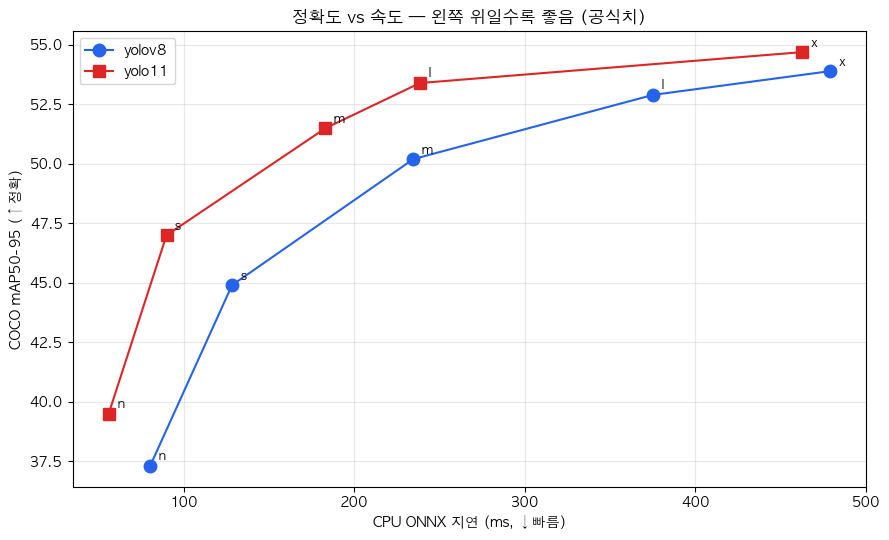

In [3]:
# ── 정확도 vs 속도 (공식) 산점도 ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))
for fam, mk, c in [("yolov8", "o", "#2563eb"), ("yolo11", "s", "#dc2626")]:
    d = off[off.family == fam]
    ax.plot(d.cpu_onnx_ms, d.mAP50_95, mk + "-", color=c, label=fam, markersize=9)
    for _, r in d.iterrows():
        ax.annotate(r["size"], (r.cpu_onnx_ms, r.mAP50_95), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("CPU ONNX 지연 (ms, ↓빠름)"); ax.set_ylabel("COCO mAP50-95 (↑정확)")
ax.set_title("정확도 vs 속도 — 왼쪽 위일수록 좋음 (공식치)"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. 로컬 실측 — 노이즈 최소화 재측정
**제출용**이라 노이즈를 줄인다: 각 모델을 **충분히 워밍업**한 뒤, 동일 이미지로 **N회 반복** 추론해
**중앙값(median)** 과 **표준편차(std)** 를 낸다. 중앙값은 순간 스파이크(백그라운드 부하·발열)에 강건하다.
스레드 수 고정, 전부 **CPU**, 입력 **640px** 고정.

> 참고: 작은 모델(n·s)은 지연이 FLOPs보다 **고정 오버헤드**에 지배되고, PyTorch eager(비-ONNX)라
> 공식 ONNX 순위와 완전히 같진 않을 수 있다. **모델 간 순위 비교는 공식 표를, 이 하드웨어의 실측 감은 아래를** 참고.

### 표 용어 설명 — 로컬 실측 컬럼

| 컬럼 | 뜻 |
|---|---|
| **local_ms_median** | 이 컴퓨터(CPU) 장당 추론시간 **중앙값**(N회 반복). ↓ 낮을수록 빠름 |
| **local_ms_std** | 반복 측정의 **표준편차**(작을수록 안정적 = 노이즈 적음) |
| **local_ms_mean** | 참고용 평균 |
| **person_avg_conf** | 검출한 person 평균 신뢰도(0~1) |

In [4]:
# ── 로컬 벤치마크 (워밍업 + 다회 반복 + 중앙값) ──────────────────
from ultralytics import YOLO

MODELS = ["yolov8n", "yolov8s", "yolov8m", "yolov8l", "yolov8x",
          "yolo11n", "yolo11s", "yolo11m", "yolo11l", "yolo11x"]
PERSON_ID = 0
IMGSZ = 640
N_WARMUP = 8       # 워밍업(스레드/캐시 안정화)
N_REPEAT = 30      # 타이밍 반복 → 중앙값 사용

try:
    torch.set_num_threads(os.cpu_count())   # 스레드 고정(재현성)
except Exception:
    pass

imgs = [Image.open(p).convert("RGB") for p in SAMPLES]
pool = [imgs[i % len(imgs)] for i in range(N_REPEAT)]    # N_REPEAT장(샘플 순환)

rows = []
for name in MODELS:
    try:
        m = YOLO(f"{name}.pt")
        for _ in range(N_WARMUP):                        # 워밍업
            m.predict(imgs[0], device="cpu", imgsz=IMGSZ, verbose=False)
        times, confs = [], []
        for im in pool:                                  # 반복 측정
            t0 = time.perf_counter()
            r = m.predict(im, device="cpu", imgsz=IMGSZ, verbose=False)[0]
            times.append((time.perf_counter() - t0) * 1000)
            cls = r.boxes.cls.cpu().numpy().astype(int); cf = r.boxes.conf.cpu().numpy()
            confs += cf[cls == PERSON_ID].tolist()
        med = round(statistics.median(times), 1)
        p25, p75 = round(float(np.percentile(times, 25)), 1), round(float(np.percentile(times, 75)), 1)
        mn, mx = round(min(times), 1), round(max(times), 1)
        rows.append({"model": name, "local_ms_median": med,
                     "local_ms_min": mn, "local_ms_max": mx,       # 최소~최대(best~worst)
                     "local_ms_p25": p25, "local_ms_p75": p75,     # IQR(사분위) — 스파이크에 강건
                     "local_ms_iqr": round(p75 - p25, 1),
                     "person_avg_conf": round(float(np.mean(confs)), 4) if confs else None})
        print(f"  {name:9s} median={med:6.1f}  min={mn:6.1f}  max={mx:6.1f}  IQR=[{p25:.0f}, {p75:.0f}]")
    except Exception as e:
        print(f"  {name:9s} 실패: {e}")
        rows.append({"model": name, "local_ms_median": None, "local_ms_min": None, "local_ms_max": None,
                     "local_ms_p25": None, "local_ms_p75": None, "local_ms_iqr": None, "person_avg_conf": None})
local = pd.DataFrame(rows)
print(f"\n(N_WARMUP={N_WARMUP}, N_REPEAT={N_REPEAT}, imgsz={IMGSZ}, CPU threads={torch.get_num_threads()})")
local

  yolov8n   median=  70.0  min=  63.4  max= 118.7  IQR=[66, 73]


  yolov8s   median=  97.3  min=  84.1  max= 133.8  IQR=[92, 102]


  yolov8m   median= 150.1  min= 140.8  max= 165.7  IQR=[146, 152]


  yolov8l   median= 207.3  min= 199.3  max= 230.4  IQR=[205, 210]


  yolov8x   median= 258.0  min= 251.5  max= 402.8  IQR=[256, 265]


...

  yolo11s   median=  81.4  min=  73.7  max= 128.1  IQR=[79, 84]


  yolo11m   median= 127.8  min= 121.4  max= 132.9  IQR=[126, 129]


  yolo11l   median= 194.3  min= 186.5  max= 212.4  IQR=[192, 197]


  yolo11x   median= 280.0  min= 271.5  max= 332.8  IQR=[275, 288]

(N_WARMUP=8, N_REPEAT=30, imgsz=640, CPU threads=8)


,model,local_ms_median,local_ms_min,local_ms_max,local_ms_p25,local_ms_p75,local_ms_iqr,person_avg_conf
0,yolov8n,70.0,63.4,118.7,66.5,73.0,6.5,0.7230
1,yolov8s,97.3,84.1,133.8,92.4,101.9,9.5,0.7763
2,yolov8m,150.1,140.8,165.7,146.5,152.4,5.9,0.7376
3,yolov8l,207.3,199.3,230.4,205.1,209.7,4.6,0.7877
4,yolov8x,258.0,251.5,402.8,255.7,264.9,9.2,0.7398
5,yolo11n,50.9,46.3,90.5,50.4,51.9,1.5,0.7141
6,yolo11s,81.4,73.7,128.1,79.3,83.6,4.3,0.7276
7,yolo11m,127.8,121.4,132.9,126.2,129.3,3.1,0.7513
8,yolo11l,194.3,186.5,212.4,192.2,197.3,5.1,0.6728
9,yolo11x,280.0,271.5,332.8,275.0,288.2,13.2,0.7263


In [5]:
# ── 공식 + 로컬 통합표 ───────────────────────────────────────────
full = off.merge(local, on="model")   # 그래프용(모든 컬럼 포함: p25/p75 등)
tbl = full[["model", "family", "size", "mAP50_95", "params_M", "FLOPs_B",
            "cpu_onnx_ms", "local_ms_median", "local_ms_iqr", "person_avg_conf"]]
tbl

,model,family,size,mAP50_95,params_M,FLOPs_B,cpu_onnx_ms,local_ms_median,local_ms_iqr,person_avg_conf
0,yolov8n,yolov8,n,37.3,3.2,8.7,80.4,70.0,6.5,0.7230
1,yolov8s,yolov8,s,44.9,11.2,28.6,128.4,97.3,9.5,0.7763
2,yolov8m,yolov8,m,50.2,25.9,78.9,234.7,150.1,5.9,0.7376
3,yolov8l,yolov8,l,52.9,43.7,165.2,375.2,207.3,4.6,0.7877
4,yolov8x,yolov8,x,53.9,68.2,257.8,479.1,258.0,9.2,0.7398
5,yolo11n,yolo11,n,39.5,2.6,6.5,56.1,50.9,1.5,0.7141
6,yolo11s,yolo11,s,47.0,9.4,21.5,90.0,81.4,4.3,0.7276
7,yolo11m,yolo11,m,51.5,20.1,68.0,183.2,127.8,3.1,0.7513
8,yolo11l,yolo11,l,53.4,25.3,86.9,238.6,194.3,5.1,0.6728
9,yolo11x,yolo11,x,54.7,56.9,194.9,462.8,280.0,13.2,0.7263


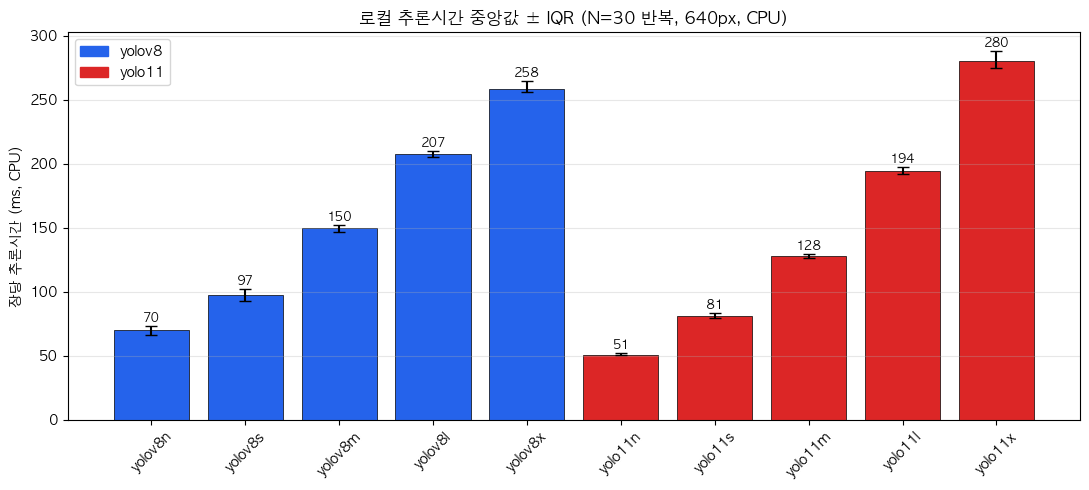

In [6]:
# ── 그래프 1: 로컬 장당 추론시간(중앙값) + IQR 오차막대 ──────────
t = full.dropna(subset=["local_ms_median"]).reset_index(drop=True)
lo = (t["local_ms_median"] - t["local_ms_p25"]).clip(lower=0).values
hi = (t["local_ms_p75"] - t["local_ms_median"]).clip(lower=0).values
colors = t["family"].map({"yolov8": "#2563eb", "yolo11": "#dc2626"})
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(t["model"], t["local_ms_median"], yerr=[lo, hi], capsize=4,
       color=colors, edgecolor="black", linewidth=0.5)
for x, v, h in zip(range(len(t)), t["local_ms_median"], hi):
    ax.text(x, v + h + 3, f"{v:.0f}", ha="center", fontsize=9)
ax.set_ylabel("장당 추론시간 (ms, CPU)")
ax.set_title("로컬 추론시간 중앙값 ± IQR (N=30 반복, 640px, CPU)")
ax.tick_params(axis="x", rotation=45); ax.grid(axis="y", alpha=.3)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color="#2563eb", label="yolov8"),
                   mpatches.Patch(color="#dc2626", label="yolo11")])
plt.tight_layout(); plt.show()

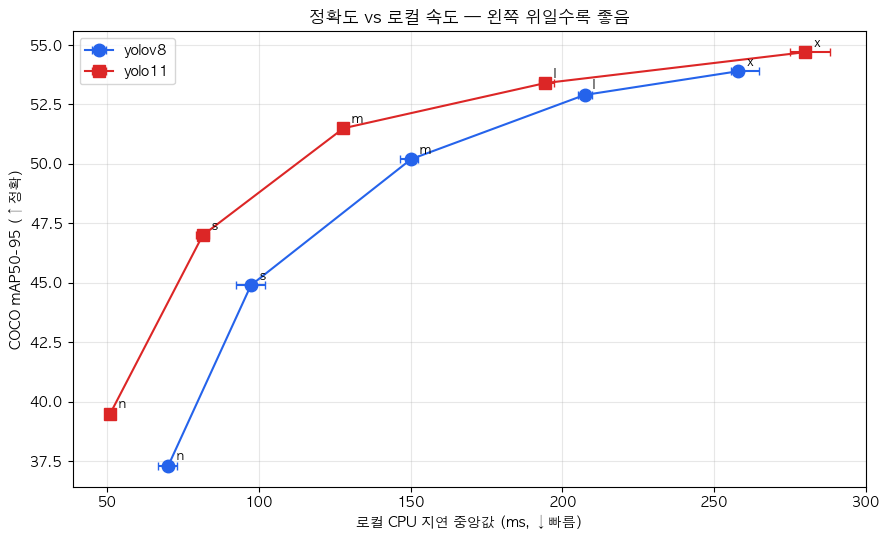

In [7]:
# ── 그래프 2: 정확도(공식 mAP) vs 로컬 속도(중앙값) ──────────────
fig, ax = plt.subplots(figsize=(9, 5.5))
for fam, mk, c in [("yolov8", "o", "#2563eb"), ("yolo11", "s", "#dc2626")]:
    d = t[t.family == fam].sort_values("local_ms_median")
    xlo = (d.local_ms_median - d.local_ms_p25).clip(lower=0).values
    xhi = (d.local_ms_p75 - d.local_ms_median).clip(lower=0).values
    ax.errorbar(d.local_ms_median, d.mAP50_95, xerr=[xlo, xhi], fmt=mk + "-",
                color=c, label=fam, markersize=9, capsize=3)
    for _, r in d.iterrows():
        ax.annotate(r["size"], (r.local_ms_median, r.mAP50_95),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("로컬 CPU 지연 중앙값 (ms, ↓빠름)"); ax.set_ylabel("COCO mAP50-95 (↑정확)")
ax.set_title("정확도 vs 로컬 속도 — 왼쪽 위일수록 좋음"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 그래프 3: 모델별 최소값 · 최대값 (best~worst case)
반복 측정 중 **가장 빠른(min)** 과 **가장 느린(max)** 추론시간. 두 값 사이가 그 모델의 지연 변동 범위다.

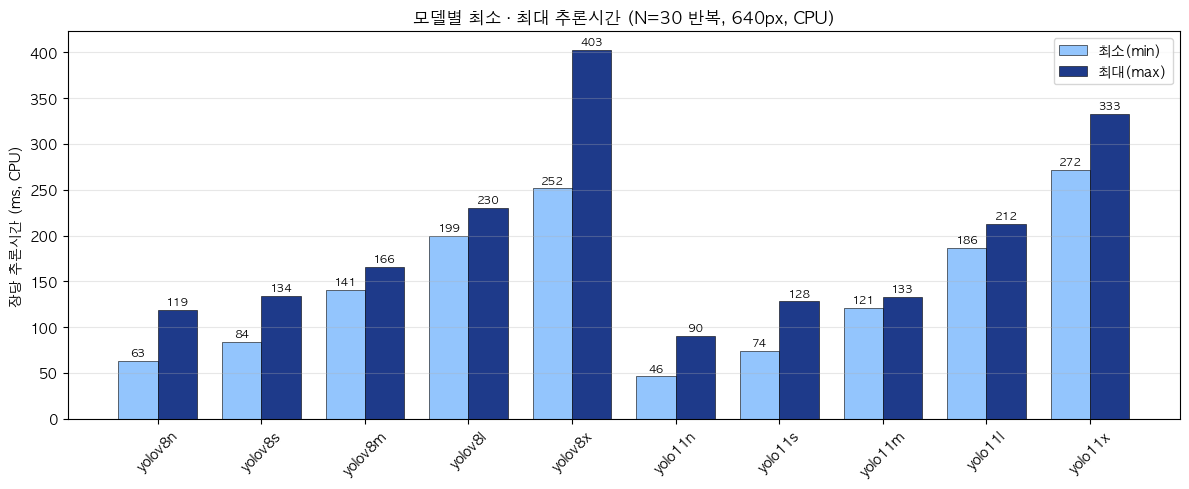

In [8]:
# ── 그래프 3: 모델별 최소/최대 추론시간 (grouped bar) ────────────
t = full.dropna(subset=["local_ms_min"]).reset_index(drop=True)
x = np.arange(len(t)); w = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, t["local_ms_min"], w, label="최소(min)", color="#93c5fd", edgecolor="black", linewidth=0.4)
b2 = ax.bar(x + w/2, t["local_ms_max"], w, label="최대(max)", color="#1e3a8a", edgecolor="black", linewidth=0.4)
for rects in (b1, b2):
    for r in rects:
        ax.text(r.get_x() + r.get_width()/2, r.get_height() + 3, f"{r.get_height():.0f}",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(t["model"], rotation=45)
ax.set_ylabel("장당 추론시간 (ms, CPU)")
ax.set_title("모델별 최소 · 최대 추론시간 (N=30 반복, 640px, CPU)")
ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

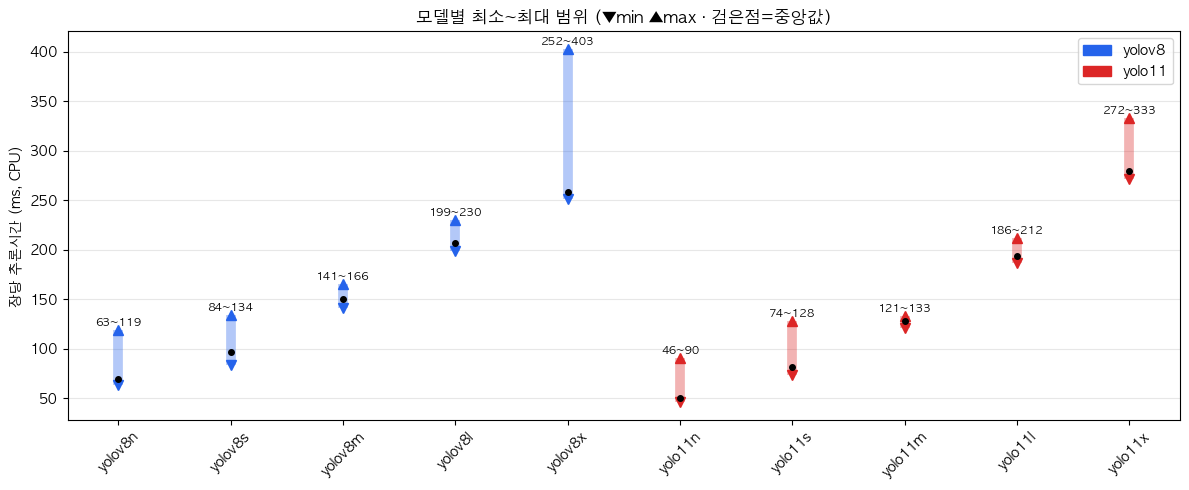

In [9]:
# ── (참고) 그래프 3b: 최소~최대 범위 막대 + 중앙값 점 ─────────────
fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, r) in enumerate(t.iterrows()):
    c = "#2563eb" if r.family == "yolov8" else "#dc2626"
    ax.vlines(i, r.local_ms_min, r.local_ms_max, color=c, linewidth=7, alpha=.35)
    ax.plot(i, r.local_ms_min, "v", color=c, markersize=7)
    ax.plot(i, r.local_ms_max, "^", color=c, markersize=7)
    ax.plot(i, r.local_ms_median, "o", color="black", markersize=4)
    ax.text(i, r.local_ms_max + 4, f"{r.local_ms_min:.0f}~{r.local_ms_max:.0f}", ha="center", fontsize=8)
ax.set_xticks(range(len(t))); ax.set_xticklabels(t["model"], rotation=45)
ax.set_ylabel("장당 추론시간 (ms, CPU)")
ax.set_title("모델별 최소~최대 범위 (▼min ▲max · 검은점=중앙값)")
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color="#2563eb", label="yolov8"),
                   mpatches.Patch(color="#dc2626", label="yolo11")])
ax.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

## 3. 해석 & 추천 (내 의견)

### 표에서 읽히는 것
- **크기(n→x)**: 커질수록 정확도↑·속도↓. 로컬에서도 오차막대(std)가 작아 순위가 안정적으로 나온다.
- **버전(v8→11)**: 공식 기준 같은 크기에서 **11이 더 정확**하고 연산량은 비슷하거나 적다.
  (단 PyTorch eager-CPU 실측은 11의 새 블록 특성상 아주 작은 n·s에서 v8과 접전일 수 있음 — 순위는 공식표 기준으로 볼 것.)

### 이 레포 관점
- YOLO는 `/detect-image`에서 도는데 **CPU**로 실행 중(models/yolo.py, device 미지정 → CPU).
- 용도가 **드론 촬영본의 person 검출**이라 정확도가 실질적 도움. 실시간 호출 주기(0.3s)면 지연도 봐야 함.

### 추천
1. **최소: `yolov8n` → `yolo11n`** — 공식 기준 더 정확(+2p)하고 더 가벼움.
2. **여유 있으면 `yolo11m`** — 정확도 대폭↑. CPU 지연은 위 그래프로 예산 확인.
3. `l`/`x`는 이득 대비 비용이 커 GPU 서버 아니면 비권장.
4. 속도 더 필요하면 **ONNX export**(공식과 동일 조건, FLOPs 순위대로 깔끔)나 GPU/MPS 검토.

> 교체는 `models/yolo.py`의 `YOLO("yolov8n.pt")` 한 줄만 바꾸면 됨.